# Neural Network
A Neural Network is a computational model inspired by human neural system. It consists of interconnected nodes that processes data and finds patterns and make predictions.

As for the similarities between biological neuron and an artifical one:
- Dendrites which act as input become the input features (x<sub>1</sub>, x<sub>2</sub>, x<sub>3</sub> ...)
- Cell body which helps in processing becomes weighted sum (∑w<sub>i​</sub>x<sub>i​</sub>​+b)
- Axon which helps with transmission becomes the activation function
- Synapse which helps with output become the model output (y)

# Perceptron

The perceptron is the most form of a artifical neuron, consisting of a single neural layer to make up the system. It takes multiple binary inputs, applies weights to them, and produces a single binary output based on a threshold. It consists of:
- Weights (w): Determine the importance of each input
- Bias (b): Allows the model to shift the activation function
- Activation Function: Decides if the neuron fires or not

In [67]:
import numpy as np

class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        # Initialize weights to small random numbers instead of zeros for faster convergence
        self.w_ = np.random.randn(1 + X.shape[1]) * 0.01
        self.errors_ = []

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                update = self.lr * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def predict(self, X):
        # Linear combination: z = w*x + b
        z = np.dot(X, self.w_[1:]) + self.w_[0]
        # Activation Function: Step function
        return np.where(z >= 0.0, 1, 0)



We use the predict function for forward propagation where data flows from input to output to produce a output

Loss function is calculated by finding the difference between predicted and actual outputs

The loss function is then further used for back propagation where the weights are further nudged in the right direction

# Testing on Sonar dataset

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/undocumented/connectionist-bench/sonar/sonar.all-data"
df = pd.read_csv(url, header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [55]:
df[60].unique()

array(['R', 'M'], dtype=object)

In [56]:
# Separate Features (X) and Target (y)
X = df.iloc[:, 0:60].values
y = df.iloc[:, 60].values

# Encode labels: Mine (M) = 1, Rock (R) = 0
le = LabelEncoder()
y = le.fit_transform(y) 

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [74]:
# Train the model
model = Perceptron()
model.fit(X_train_std, y_train)

Final Accuracy on Sonar Test Set: 80.95%


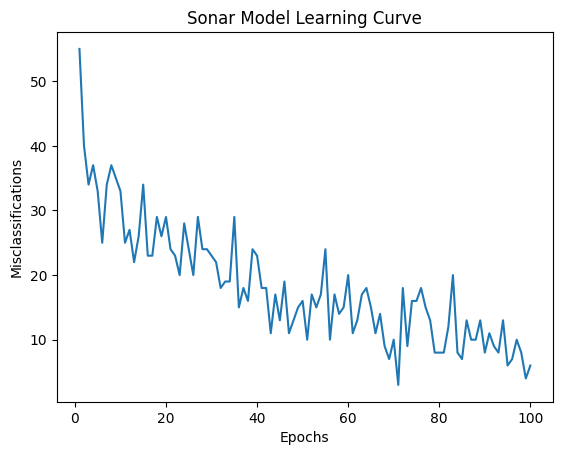

In [75]:
# Check performance
test_preds = model.predict(X_test_std)
accuracy = np.mean(test_preds == y_test) * 100

print(f"Final Accuracy on Sonar Test Set: {accuracy:.2f}%")

# Plot training progress
plt.plot(range(1, len(model.errors_) + 1), model.errors_)
plt.xlabel('Epochs')
plt.ylabel('Misclassifications')
plt.title('Sonar Model Learning Curve')
plt.show()